# E1 · Huấn luyện đầy đủ Fashion-MNIST trên GPU
**CO5085 · Học kỳ 261 · Notebook độc lập · Softmax classifier, MLP, CNN-A, CNN-B**

**Restart Kernel → Run All** chạy toàn bộ pipeline từ đầu: kiểm tra GPU/dataset,
khởi tạo model mới → train theo mini-batch → validation/early stopping →
nạp checkpoint tốt nhất của lần train này → test → bảng/đồ thị/phân tích → hiển thị kết quả trong cell.

| Tập | Số ảnh | Vai trò |
|---|---:|---|
| Train | 54.000 | Cập nhật trọng số |
| Validation | 6.000 | Chọn checkpoint, early stopping |
| Test chính thức | 10.000 | Đánh giá sau khi chọn checkpoint |

Đây là toàn bộ 70.000 ảnh Fashion-MNIST: 60.000 ảnh nguồn train tách thành
54.000 train + 6.000 validation, giữ nguyên test 10.000. Không lấy tập con.
Seed42 và cấu hình thống nhất cho mọi model. Các bảng và biểu đồ trình bày
metric thực nghiệm trên validation/test.

Batch 128 → **422 batch/epoch/model**. Tối đa 100 epoch; dừng khi validation loss
không cải thiện ít nhất 0,0001 trong 4 epoch liên tiếp. Test không dùng early stop.
Bắt buộc CUDA; log xác nhận model, dữ liệu, logits và gradient nằm trên GPU.

**Đóng góp học thuật:** kiểm chứng code, hiểu kết quả, viết phân tích từ số liệu thật
và ghi rõ phần AI hỗ trợ theo mục 1.6 của đề.

## 1. Môi trường và cấu hình

In [1]:
import copy
import hashlib
import importlib.metadata
import json
import math
import os
import random
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(min(8, os.cpu_count() or 1))
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

SESSION_STARTED = time.perf_counter()
EXECUTION_LOG = []


def log(stage, message, model=None, *, console=True):
    prefix = f"[{time.strftime('%H:%M:%S')}] [{stage}]"
    if model:
        prefix += f" [{model}]"
    line = f"{prefix} {message}"
    EXECUTION_LOG.append(line)
    if console:
        print(line, flush=True)


log("MÔI TRƯỜNG", "Đã import PyTorch, NumPy, Matplotlib và tiện ích báo cáo.")


class TextProgress:
    """Update one plain-text display per model without clearing other outputs."""

    def __init__(self, model):
        self.model = model
        self.started = time.perf_counter()
        self.phase_started = self.started
        self.last_refresh = 0.0
        self.state = {
            "phase": "Chuẩn bị",
            "epoch": 0,
            "max_epochs": MAX_EPOCHS,
            "step": 0,
            "batches": 0,
            "samples": 0,
            "total_samples": 0,
            "loss": None,
            "accuracy": None,
            "updates": 0,
            "skips": 0,
            "vram": 0.0,
            "train_verified": False,
            "eval_verified": False,
            "validation": "Chưa đánh giá",
            "test": "Chưa đánh giá",
            "checkpoint": "Chưa chọn",
            "bad": 0,
            "patience": EARLY_STOP_PATIENCE,
            "min_delta": EARLY_STOP_MIN_DELTA,
            "status": "Khởi tạo model",
        }
        self.gpu = torch.cuda.get_device_name(DEVICE)
        self.handle = display({"text/plain": self.render()}, raw=True, display_id=True)

    @staticmethod
    def bar(current, total, width=24):
        fraction = min(1.0, max(0.0, current / total)) if total else 0.0
        filled = int(width * fraction)
        return "[" + "#" * filled + "-" * (width - filled) + f"] {100 * fraction:5.1f}%"

    @staticmethod
    def duration(seconds):
        minutes, seconds = divmod(max(0, int(seconds)), 60)
        hours, minutes = divmod(minutes, 60)
        return f"{hours:02}:{minutes:02}:{seconds:02}"

    def start_phase(self, phase, batches, total_samples, **changes):
        self.phase_started = time.perf_counter()
        self.update(
            force=True,
            phase=phase,
            batches=batches,
            total_samples=total_samples,
            step=0,
            samples=0,
            loss=None,
            accuracy=None,
            **changes,
        )

    def update(self, *, force=False, **changes):
        self.state.update(changes)
        now = time.perf_counter()
        if not force and now - self.last_refresh < PROGRESS_REFRESH_SECONDS:
            return
        payload = {"text/plain": self.render()}
        if self.handle is not None:
            self.handle.update(payload, raw=True)
        self.last_refresh = now

    def render(self):
        s = self.state
        elapsed = time.perf_counter() - self.started
        phase_elapsed = time.perf_counter() - self.phase_started
        eta = (
            self.duration(phase_elapsed * (s["batches"] - s["step"]) / s["step"])
            if s["step"]
            else "--:--:--"
        )
        loss = f"{s['loss']:.4f}" if s["loss"] is not None else "----"
        accuracy = (
            f"{100 * s['accuracy']:.2f}%" if s["accuracy"] is not None else "----"
        )
        train_proof = (
            "parameters/images/labels/logits/gradient: CUDA xác nhận"
            if s["train_verified"]
            else "train: chờ xác nhận tensor/gradient CUDA"
        )
        eval_proof = " | eval: CUDA xác nhận" if s["eval_verified"] else ""
        return "\n".join(
            [
                f"{self.model} | GPU: {self.gpu} | device={DEVICE} | AMP train",
                f"Epoch {s['epoch']}/{s['max_epochs']} (giới hạn; có early stopping)",
                f"{s['phase']} {self.bar(s['step'], s['batches'])} | batch {s['step']}/{s['batches']} | ảnh {s['samples']:,}/{s['total_samples']:,}",
                f"Loss={loss} | Accuracy={accuracy} | Updates train/epoch={s['updates']} | AMP skips train/epoch={s['skips']} | VRAM={s['vram']:.0f} MiB",
                f"Validation: {s['validation']}",
                f"Test: {s['test']}",
                f"Checkpoint: {s['checkpoint']} | Early stop={s['bad']}/{s['patience']} | min_delta={s['min_delta']:g}",
                train_proof + eval_proof,
                f"Thời gian từ khi bắt đầu run={self.duration(elapsed)} | ETA pha hiện tại≈{eta} | {s['status']}",
            ]
        )

[02:25:02] [MÔI TRƯỜNG] Đã import PyTorch, NumPy, Matplotlib và tiện ích báo cáo.


In [2]:
NAME = "E1"
DATA_SCOPE = "Fashion-MNIST đầy đủ"
SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 1e-4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LOG_BATCH_EVERY = 50  # Chỉ ghi log chi tiết trong RAM; không in từng batch.
PROGRESS_REFRESH_SECONDS = 0.25  # Giới hạn tần suất cập nhật display text.
NUM_WORKERS = 0  # Data đã ở RAM; Windows notebook không spawn worker local.
if not torch.cuda.is_available():
    raise RuntimeError(
        "E1 bắt buộc GPU CUDA. Chọn kernel Python 3.14 (CO5085) với PyTorch CUDA; "
        "kiểm tra torch.cuda.is_available(). Notebook không chuyển ngầm sang CPU."
    )
DEVICE = torch.device("cuda:0")
ROOT = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "assignment" / "exercise-vne.pdf").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Open E1 from the CO5085 project or source_code folder.")
RUN_ID = (
    datetime.now(timezone.utc).astimezone().strftime("%Y%m%d_%H%M%S")
    + "_"
    + uuid4().hex[:6]
)
RUN_CONFIGS = {}

CHECKPOINTS = {}


MODEL_LABELS = {
    "linear": "Softmax classifier",
    "mlp": "MLP",
    "cnn_a": "CNN-A",
    "cnn_b": "CNN-B",
}
MODEL_COLORS = {
    "linear": "#0072B2",
    "mlp": "#E69F00",
    "cnn_a": "#009E73",
    "cnn_b": "#CC79A7",
}

VERSIONS = {
    p: importlib.metadata.version(p)
    for p in ["torch", "torchvision", "numpy", "matplotlib", "Pillow"]
}
properties = torch.cuda.get_device_properties(DEVICE)
log("CẤU HÌNH", f"{DATA_SCOPE} | run={RUN_ID} | seed={SEED} | huấn luyện")
log(
    "GPU",
    f"CUDA available=True | device={DEVICE} | {properties.name} | VRAM tổng={properties.total_memory / 2**30:.2f} GiB | torch CUDA={torch.version.cuda}",
)
log("PYTHON", f"{sys.version.split()[0]} | interpreter={sys.executable}")
log("PHIÊN BẢN", ", ".join(f"{p}={v}" for p, v in VERSIONS.items()))
log(
    "CẤU HÌNH",
    f"batch={BATCH_SIZE} | tối đa {MAX_EPOCHS} epoch | AdamW lr={LEARNING_RATE:g}, wd={WEIGHT_DECAY:g}",
)
log(
    "EARLY STOPPING",
    f"Monitor validation loss | min_delta={EARLY_STOP_MIN_DELTA:g} | patience={EARLY_STOP_PATIENCE} epoch",
)
log("KẾT QUẢ", "Kết quả trong output cell; checkpoint tốt nhất giữ trong RAM.")
probe = torch.randn(64, 64, device=DEVICE)
probe_result = probe @ probe
torch.cuda.synchronize()
assert probe.is_cuda and probe_result.is_cuda
log(
    "GPU PREFLIGHT",
    f"Phép nhân tensor đã chạy trên {probe_result.device}; CUDA hoạt động.",
)
del probe, probe_result
log(
    "HIỂN THỊ",
    "Train/validation/test cập nhật một khung text/model tại chỗ; log chi tiết giữ trong EXECUTION_LOG (RAM).",
)

[02:25:02] [CẤU HÌNH] Fashion-MNIST đầy đủ | run=20261007_022502_6f922c | seed=42 | huấn luyện
[02:25:02] [GPU] CUDA available=True | device=cuda:0 | NVIDIA RTX A3000 12GB Laptop GPU | VRAM tổng=12.00 GiB | torch CUDA=12.8
[02:25:02] [PYTHON] 3.14.7 | interpreter=C:\Users\DELL\AppData\Local\Programs\Python\Python314\python.exe
[02:25:02] [PHIÊN BẢN] torch=2.11.0+cu128, torchvision=0.26.0+cu128, numpy=2.5.2, matplotlib=3.11.2, Pillow=12.3.0
[02:25:02] [CẤU HÌNH] batch=128 | tối đa 100 epoch | AdamW lr=0.001, wd=0.0001
[02:25:02] [EARLY STOPPING] Monitor validation loss | min_delta=0.0001 | patience=10 epoch
[02:25:02] [KẾT QUẢ] Kết quả trong output cell; checkpoint tốt nhất giữ trong RAM.
[02:25:03] [GPU PREFLIGHT] Phép nhân tensor đã chạy trên cuda:0; CUDA hoạt động.
[02:25:03] [HIỂN THỊ] Train/validation/test cập nhật một khung text/model tại chỗ; log chi tiết giữ trong EXECUTION_LOG (RAM).


### Tiện ích tái lập và checkpoint trong RAM

In [3]:
def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def digest(value):
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, default=str).encode()
    ).hexdigest()


def snapshot(value):
    """Freeze CPU tensor/array copies so later training cannot change a best state."""
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, np.ndarray):
        return value.copy()
    if isinstance(value, dict):
        return {key: snapshot(item) for key, item in value.items()}
    if isinstance(value, list):
        return [snapshot(item) for item in value]
    if isinstance(value, tuple):
        return tuple(snapshot(item) for item in value)
    return copy.deepcopy(value)


def remember_checkpoint(run, state):
    """Freeze the best model's weights in CPU RAM."""
    CHECKPOINTS[run] = snapshot(state)


def load_checkpoint(run):
    """Return the validation-selected weights for this experiment."""
    return CHECKPOINTS[run]


def show_figure(fig, stem):
    if fig.get_layout_engine() is None:
        fig.tight_layout()
    print(f"[HÌNH] {stem} · hiển thị trong output cell", flush=True)
    plt.show()
    plt.close(fig)


def finish_notebook():
    CHECKPOINTS.clear()
    log("THÍ NGHIỆM", f"Hoàn tất đánh giá {len(results)} model trên toàn bộ test.")


seed_all(SEED)
log("TIỆN ÍCH", "Đã định nghĩa seed, protocol, checkpoint RAM và trình bày bảng/hình.")

[02:25:03] [TIỆN ÍCH] Đã định nghĩa seed, protocol, checkpoint RAM và trình bày bảng/hình.


## 2. Toàn bộ dữ liệu và split
Đọc/checksum đủ 54.000 train, 6.000 validation, 10.000 test. Normalization chỉ từ train; cả ba split được giữ đầy đủ.

In [4]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
CACHE = Path(
    os.environ.get("FASHION_MNIST_ROOT", str(ROOT / "datasets" / "fashion_mnist"))
)
log("DỮ LIỆU", f"Đọc Fashion-MNIST: {CACHE}")
metadata_path = CACHE / "metadata.json"
if not metadata_path.is_file():
    raise FileNotFoundError(
        f"Prepared Fashion-MNIST missing: {metadata_path}. Copy datasets/fashion_mnist with train/val/test."
    )
METADATA = json.loads(metadata_path.read_text(encoding="utf-8"))
assert METADATA["schema"] == 1 and METADATA["seed"] == 42
mean, std = METADATA["normalization"]["mean"], METADATA["normalization"]["std"]
assert math.isfinite(mean) and math.isfinite(std) and 0 < std <= 1 and 0 <= mean <= 1


def prepared_fashion(split):
    started = time.perf_counter()
    log("KIỂM TRA DỮ LIỆU", f"Đọc/checksum split {split}.")
    folder = CACHE / split
    for filename, checksum in METADATA["splits"][split]["sha256"].items():
        with (folder / filename).open("rb") as stream:
            assert hashlib.file_digest(stream, "sha256").hexdigest() == checksum, (
                filename
            )
    pixels = np.load(folder / "images.npy", allow_pickle=False)
    labels = np.load(folder / "labels.npy", allow_pickle=False)
    index_array = np.load(folder / "indices.npy", allow_pickle=False)
    assert labels.ndim == 1 and np.issubdtype(labels.dtype, np.integer)
    assert ((labels >= 0) & (labels < len(CLASS_NAMES))).all()
    assert index_array.shape == labels.shape and np.issubdtype(
        index_array.dtype, np.integer
    )
    assert len(np.unique(index_array)) == len(index_array)
    source_size = 10000 if split == "test" else 60000
    assert ((index_array >= 0) & (index_array < source_size)).all()
    indices = index_array.tolist()
    assert pixels.dtype == np.uint8 and pixels.shape == (len(labels), 28, 28)
    assert len(labels) == METADATA["splits"][split]["count"]
    images = (torch.from_numpy(pixels).float().unsqueeze(1) / 255 - mean) / std
    log(
        "KIỂM TRA DỮ LIỆU",
        f"{split}: {len(labels):,} ảnh, shape={tuple(images.shape)}, hợp lệ ({time.perf_counter() - started:.2f}s).",
    )
    return TensorDataset(images, torch.from_numpy(labels.astype(np.int64))), indices


train_set, train_indices = prepared_fashion("train")
val_set, val_indices = prepared_fashion("val")
test_set, _ = prepared_fashion("test")
assert len(train_set) == 54000 and len(val_set) == 6000 and len(test_set) == 10000
assert not set(train_indices) & set(val_indices)
assert sorted(train_indices + val_indices) == list(range(60000))
SPLIT_HASH = digest(
    {"train": train_indices, "val": val_indices, "normalization": [mean, std]}
)
assert SPLIT_HASH == METADATA["split_hash"]


def dataset_labels(dataset):
    return dataset.tensors[1].numpy()


log(
    "SPLIT",
    f"{len(train_set):,} train / {len(val_set):,} validation; test có {len(test_set):,} ảnh.",
)
log("SPLIT", f"Hash={SPLIT_HASH}, mean={mean:.6f}, std={std:.6f}")
display(
    Markdown(
        "| Tập | Đầy đủ | Dùng lần này | Vai trò |\n|---|---:|---:|---|\n"
        f"| Train | 54.000 | {len(train_set):,} | Cập nhật trọng số |\n"
        f"| Validation | 6.000 | {len(val_set):,} | Chọn checkpoint, early stopping |\n"
        f"| Test | 10.000 | {len(test_set):,} | Đánh giá sau chọn checkpoint |"
    )
)
log(
    "MINI-BATCH",
    f"Train {math.ceil(len(train_set) / BATCH_SIZE)} batch/epoch; validation {math.ceil(len(val_set) / BATCH_SIZE)} batch; test {math.ceil(len(test_set) / BATCH_SIZE)} batch; không bỏ batch cuối.",
)

[02:25:03] [DỮ LIỆU] Đọc Fashion-MNIST: C:\Users\DELL\Desktop\CO5085\datasets\fashion_mnist
[02:25:03] [KIỂM TRA DỮ LIỆU] Đọc/checksum split train.
[02:25:03] [KIỂM TRA DỮ LIỆU] train: 54,000 ảnh, shape=(54000, 1, 28, 28), hợp lệ (0.11s).
[02:25:03] [KIỂM TRA DỮ LIỆU] Đọc/checksum split val.
[02:25:03] [KIỂM TRA DỮ LIỆU] val: 6,000 ảnh, shape=(6000, 1, 28, 28), hợp lệ (0.03s).
[02:25:03] [KIỂM TRA DỮ LIỆU] Đọc/checksum split test.
[02:25:03] [KIỂM TRA DỮ LIỆU] test: 10,000 ảnh, shape=(10000, 1, 28, 28), hợp lệ (0.04s).
[02:25:03] [SPLIT] 54,000 train / 6,000 validation; test có 10,000 ảnh.
[02:25:03] [SPLIT] Hash=bd9f3884131e411a26892e15ff685f2849216340505ea615f3fb3b901e30fe80, mean=0.285886, std=0.352960
[02:25:03] [MINI-BATCH] Train 422 batch/epoch; validation 47 batch; test 79 batch; không bỏ batch cuối.


| Tập | Đầy đủ | Dùng lần này | Vai trò |
|---|---:|---:|---|
| Train | 54.000 | 54,000 | Cập nhật trọng số |
| Validation | 6.000 | 6,000 | Chọn checkpoint, early stopping |
| Test | 10.000 | 10,000 | Đánh giá sau chọn checkpoint |

## 3. Khảo sát dữ liệu
Ảnh mẫu có tên lớp; biểu đồ bên phải đếm train/validation **thực sự dùng**.

[02:25:03] [EDA] Gộp ví dụ 10 lớp và phân bố train/validation trong một hình.
[HÌNH] dataset_overview · hiển thị trong output cell


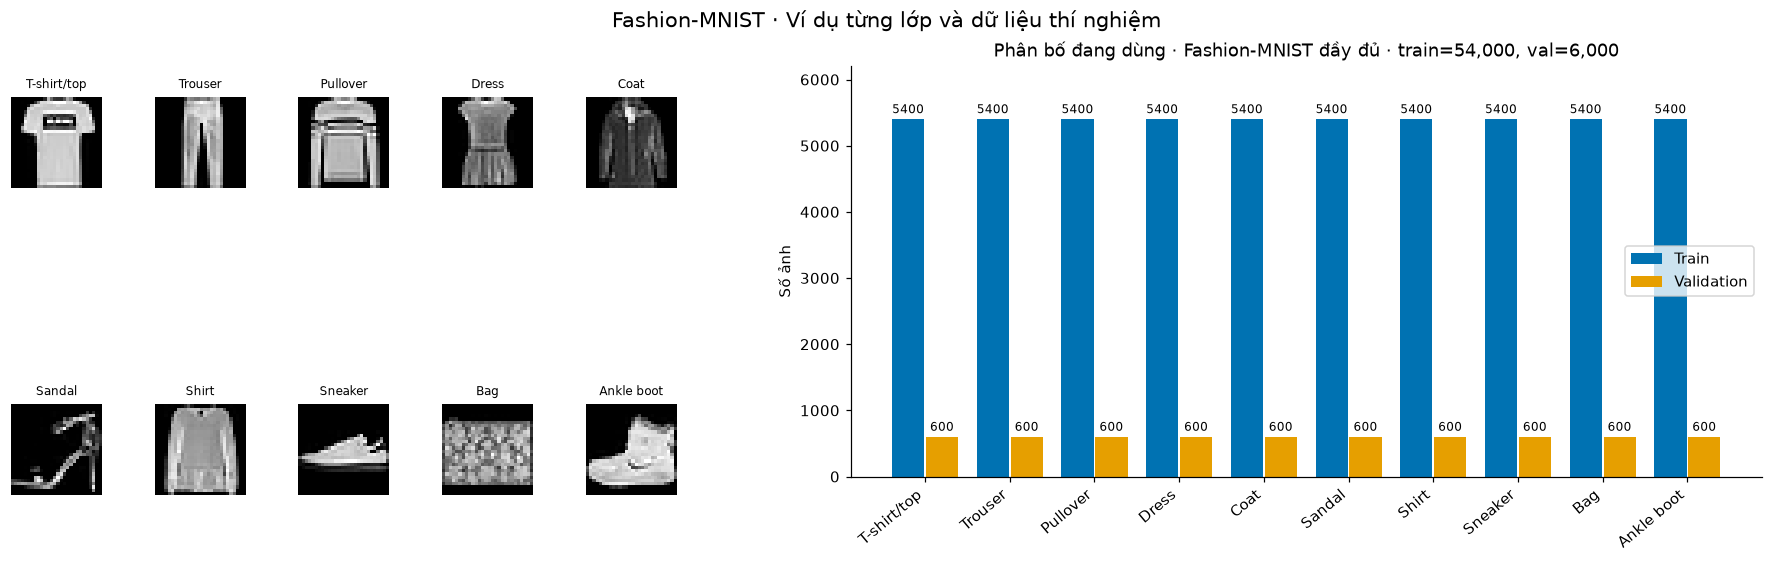

In [5]:
log("EDA", "Gộp ví dụ 10 lớp và phân bố train/validation trong một hình.")
eda_images = np.load(CACHE / "train/images.npy", mmap_mode="r", allow_pickle=False)
eda_labels = np.load(CACHE / "train/labels.npy", allow_pickle=False)
fig = plt.figure(figsize=(16, 5), layout="constrained")
grid = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.22)
gallery = grid[0].subgridspec(2, 5, wspace=0.15, hspace=0.38)
for label in range(10):
    ax = fig.add_subplot(gallery[label // 5, label % 5])
    ax.imshow(eda_images[np.flatnonzero(eda_labels == label)[0]], cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=8)
    ax.axis("off")
ax = fig.add_subplot(grid[1])
positions = np.arange(10)
for offset, dataset, label, color in [
    (-0.2, train_set, "Train", "#0072B2"),
    (0.2, val_set, "Validation", "#E69F00"),
]:
    counts = np.bincount(dataset_labels(dataset), minlength=10)
    bars = ax.bar(positions + offset, counts, width=0.38, label=label, color=color)
    ax.bar_label(bars, fontsize=8, padding=2)
ax.set_xticks(positions, CLASS_NAMES, rotation=40, ha="right")
ax.set_ylabel("Số ảnh")
ax.set_title(
    f"Phân bố đang dùng · {DATA_SCOPE} · train={len(train_set):,}, val={len(val_set):,}"
)
ax.margins(y=0.15)
ax.legend()
fig.suptitle("Fashion-MNIST · Ví dụ từng lớp và dữ liệu thí nghiệm", fontsize=14)
show_figure(fig, "dataset_overview")

## 4. Kiến trúc: Softmax, MLP và CNN
| Tên báo cáo | Mã checkpoint | Kiến trúc | Khả năng biểu diễn |
|---|---|---|---|
| **Softmax classifier** | linear | Flatten 784 → Linear 10 | Baseline tuyến tính |
| **MLP** | mlp | 784 → 256 → 128 → 10; ReLU/dropout 0,2 | Phi tuyến, không trực tiếp dùng cấu trúc không gian |
| **CNN-A** | cnn_a | Conv 32/64 + pooling → FC128 → 10 | Đặc trưng không gian, head fully connected |
| **CNN-B** | cnn_b | Conv 32/64/128 + BN/pooling → global pooling → 10 | Head nhỏ hơn, inductive bias khác CNN-A |

Model trả về **logits** cho cross_entropy (đã tính log-softmax bên trong).
Xác suất là softmax(logits, dim=1); nhãn là argmax. Linear chính là softmax
classifier trong đề, không phải hồi quy. Không softmax hai lần trước loss.

In [6]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

    def forward(self, x):
        return self.net(x)  # CrossEntropyLoss takes logits; softmax only for inference.


class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


class SmallCNN(nn.Module):
    def __init__(self, variant="B"):
        super().__init__()
        if variant == "A":
            self.net = nn.Sequential(
                nn.Conv2d(1, 32, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Flatten(),
                nn.Linear(64 * 7 * 7, 128),
                nn.ReLU(),
                nn.Linear(128, 10),
            )
        else:
            layers = []
            channels = 1
            for width in [32, 64, 128]:
                layers += [
                    nn.Conv2d(channels, width, 3, padding=1, bias=False),
                    nn.BatchNorm2d(width),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                ]
                channels = width
            self.net = nn.Sequential(
                *layers,
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(0.3),
                nn.Linear(128, 10),
            )

    def forward(self, x):
        return self.net(x)


factories = {
    "linear": LinearClassifier,
    "mlp": MLP,
    "cnn_a": lambda: SmallCNN("A"),
    "cnn_b": SmallCNN,
}
architecture_rows = ["| Model | Số tham số | Input | Output |", "|---|---:|---|---|"]
for run, factory in factories.items():
    model = factory()
    count = sum(p.numel() for p in model.parameters())
    architecture_rows.append(
        f"| {MODEL_LABELS[run]} | {count:,} | 1×28×28 | 10 logits |"
    )
    log("KIẾN TRÚC", f"{count:,} tham số; 10 logits.", MODEL_LABELS[run])
    del model
display(Markdown("\n".join(architecture_rows)))

[02:25:03] [KIẾN TRÚC] [Softmax classifier] 7,850 tham số; 10 logits.
[02:25:03] [KIẾN TRÚC] [MLP] 235,146 tham số; 10 logits.
[02:25:03] [KIẾN TRÚC] [CNN-A] 421,642 tham số; 10 logits.
[02:25:03] [KIẾN TRÚC] [CNN-B] 94,186 tham số; 10 logits.


| Model | Số tham số | Input | Output |
|---|---:|---|---|
| Softmax classifier | 7,850 | 1×28×28 | 10 logits |
| MLP | 235,146 | 1×28×28 | 10 logits |
| CNN-A | 421,642 | 1×28×28 | 10 logits |
| CNN-B | 94,186 | 1×28×28 | 10 logits |

## 5. Vòng lặp train trên GPU và early stopping
Forward → cross-entropy trung bình → backward → AdamW step, dùng CUDA AMP.
Mỗi epoch duyệt đủ 422 batch train (kể cả batch cuối), rồi đánh giá 47 batch validation.
Một khung text/model cập nhật tại chỗ cho train, validation và test (refresh định kỳ mỗi 0,25 giây; cập nhật ngay khi chuyển pha).
Hiển thị epoch/batch, thanh tiến trình, loss/accuracy, optimizer update, AMP skips,
GPU/VRAM, xác nhận tensor/gradient CUDA, best checkpoint và bộ đếm early stopping.
ETA chỉ ước lượng pha hiện tại; số epoch thực tế phụ thuộc early stopping.
Log chi tiết mỗi 50 batch và từng epoch giữ trong EXECUTION_LOG (RAM), không in thêm từng dòng. GradScaler có thể bỏ update nếu overflow;
số batch và số update được ghi riêng.

Tối đa 100 epoch/model. **Early stopping theo validation loss**:
cần giảm ít nhất 0,0001 để reset patience; dừng sau 4 epoch liên tiếp không đạt mức này.
Checkpoint tốt nhất luôn lưu checkpoint có validation loss thấp nhất, kể cả cải thiện nhỏ hơn min_delta.
Nạp Checkpoint tốt nhất của **lần train hiện tại** rồi đánh giá test; không chọn bằng test.

Checkpoint giữ weights có validation loss thấp nhất tuyệt đối. Patience chỉ reset khi loss cải thiện hơn `min_delta=0,0001` so với mốc dừng sớm; một cải thiện nhỏ hơn vẫn có thể tạo checkpoint tốt hơn mà không reset patience.

In [7]:
@torch.no_grad()
def evaluate(model, loader, classes, *, run, split, progress=None):
    started = time.perf_counter()
    label = MODEL_LABELS[run]
    if progress is None:
        progress = TextProgress(label)
    progress.start_phase(
        split,
        len(loader),
        len(loader.dataset),
        status="Đánh giá trên CUDA; không cập nhật trọng số",
    )
    model.eval()
    log(
        "ĐÁNH GIÁ",
        f"{split}: {len(loader.dataset):,} ảnh / {len(loader)} batch; eval/no_grad trên {DEVICE}.",
        label,
        console=False,
    )
    cm = torch.zeros(classes, classes, dtype=torch.int64)
    loss_sum, count = 0.0, 0
    failures, failure_classes = [], set()
    for step, (images_cpu, labels_cpu) in enumerate(loader, 1):
        images = images_cpu.to(DEVICE, non_blocking=True)
        labels = labels_cpu.to(DEVICE, non_blocking=True)
        logits = model(images)
        assert images.is_cuda and labels.is_cuda and logits.is_cuda
        loss = F.cross_entropy(logits, labels, reduction="sum")
        if not torch.isfinite(loss):
            raise FloatingPointError(f"{run}/{split}: non-finite evaluation loss")
        loss_sum += loss.item()
        prediction = logits.argmax(1).cpu()
        cm += torch.bincount(
            labels_cpu * classes + prediction, minlength=classes * classes
        ).reshape(classes, classes)
        if len(failure_classes) < classes:
            for j in torch.where(prediction != labels_cpu)[0].tolist():
                truth = int(labels_cpu[j])
                if truth not in failure_classes:
                    failures.append((images_cpu[j].clone(), truth, int(prediction[j])))
                    failure_classes.add(truth)
        count += len(labels)
        progress.update(
            step=step,
            samples=count,
            loss=loss_sum / count,
            accuracy=float(cm.diag().sum()) / count,
            vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
            eval_verified=True,
        )
        if step == 1:
            log(
                "GPU EVAL",
                f"images={images.device}, labels={labels.device}, logits={logits.device}; model={next(model.parameters()).device}.",
                label,
                console=False,
            )
        if step == 1 or step % LOG_BATCH_EVERY == 0 or step == len(loader):
            log(
                "EVAL BATCH",
                f"{split} · {step}/{len(loader)} · {count:,}/{len(loader.dataset):,} ảnh · loss={loss_sum / count:.4f}.",
                label,
                console=False,
            )
    assert count == len(loader.dataset) and count > 0
    tp = cm.diag().double()
    precision = tp / cm.sum(0).clamp_min(1)
    recall = tp / cm.sum(1).clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)
    result = {
        "loss": loss_sum / count,
        "accuracy": float(tp.sum() / count),
        "macro_f1": float(f1.mean()),
        "cm": cm.numpy(),
        "failures": failures,
    }
    log(
        "ĐÁNH GIÁ",
        f"Hoàn tất {split}: {count:,} ảnh · acc={100 * result['accuracy']:.2f}% · F1={result['macro_f1']:.4f} · {time.perf_counter() - started:.2f}s.",
        label,
        console=False,
    )
    evaluation_text = f"{split}: loss={result['loss']:.4f}, acc={100 * result['accuracy']:.2f}%, F1={result['macro_f1']:.4f}"
    metric = "test" if split == "test" else "validation"
    progress.update(
        force=True,
        step=len(loader),
        status=f"Hoàn tất {split}",
        **{metric: evaluation_text},
    )
    return result


def train_classifier(
    model,
    train_set,
    val_set,
    run,
    *,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOP_PATIENCE,
    min_delta=EARLY_STOP_MIN_DELTA,
    progress=None,
):
    call_started = time.perf_counter()
    if max_epochs < 1 or patience < 1 or min_delta < 0 or batch_size < 1:
        raise ValueError("Invalid training configuration")
    seed_all(SEED)
    label = MODEL_LABELS[run]
    if progress is None:
        progress = TextProgress(label)
    progress.update(
        force=True, max_epochs=max_epochs, patience=patience, min_delta=min_delta
    )
    model.to(DEVICE)
    assert all(p.is_cuda for p in model.parameters())
    assert all(b.is_cuda for b in model.buffers())

    protocol = {
        "run_id": RUN_ID,
        "run": run,
        "dataset_scope": "full",
        "seed": SEED,
        "train_samples": len(train_set),
        "val_samples": len(val_set),
        "test_samples": len(test_set),
        "max_epochs": max_epochs,
        "patience": patience,
        "min_delta": min_delta,
        "checkpoint_metric": "minimum_validation_loss",
        "lr": lr,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "split": SPLIT_HASH,
        "versions": VERSIONS,
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(DEVICE),
        "architecture": str(model),
        "fresh_initialization": True,
    }
    config_hash = digest(protocol)
    RUN_CONFIGS[run] = protocol
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda", init_scale=1024)
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    history = []
    best_loss, early_best_loss, bad = math.inf, math.inf, 0
    session_updates = 0
    stopping_reason = "maximum_epochs"
    torch.cuda.reset_peak_memory_stats(DEVICE)
    log(
        "TRAIN",
        f"Khởi tạo từ đầu · {len(train_set):,} train / {len(val_set):,} val · {len(train_loader)} batch/epoch · AdamW lr={lr:g}, weight_decay={weight_decay:g} · tối đa {max_epochs} epoch.",
        label,
        console=False,
    )
    for epoch in range(1, max_epochs + 1):
        torch.cuda.synchronize(DEVICE)
        started = time.perf_counter()
        log(
            "TRAIN",
            f"Epoch {epoch}/{max_epochs} · GPU={torch.cuda.get_device_name(DEVICE)} · {len(train_loader)} batch cập nhật trọng số.",
            label,
            console=False,
        )
        progress.start_phase(
            "TRAIN",
            len(train_loader),
            len(train_set),
            epoch=epoch,
            updates=0,
            skips=0,
            status="Forward → backward → AdamW trên CUDA",
        )
        model.train()
        total_loss, total, correct, optimizer_updates, skipped_updates = 0.0, 0, 0, 0, 0
        for step, (images, labels) in enumerate(train_loader, 1):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda"):
                logits = model(images)
                loss = F.cross_entropy(logits, labels)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"{run}: non-finite training loss")
            scaler.scale(loss).backward()
            if step == 1:
                gradients = [p.grad for p in model.parameters() if p.requires_grad]
                assert images.is_cuda and labels.is_cuda and logits.is_cuda
                assert all(g is not None and g.is_cuda for g in gradients)
                progress.update(train_verified=True)
                log(
                    "GPU TRAIN",
                    f"parameters={next(model.parameters()).device}; images={images.device}; labels={labels.device}; logits={logits.device}; gradient={gradients[0].device}; AMP=True.",
                    label,
                    console=False,
                )
            old_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            updated = scaler.get_scale() >= old_scale
            optimizer_updates += int(updated)
            skipped_updates += int(not updated)
            if not updated:
                log(
                    "AMP",
                    f"Epoch {epoch} batch {step}: overflow, bỏ optimizer update; scale {old_scale:g} → {scaler.get_scale():g}.",
                    label,
                    console=False,
                )
            total_loss += loss.item() * len(labels)
            total += len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            progress.update(
                step=step,
                samples=total,
                loss=total_loss / total,
                accuracy=correct / total,
                updates=optimizer_updates,
                skips=skipped_updates,
                vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
                force=step == len(train_loader),
            )
            if step == 1 or step % LOG_BATCH_EVERY == 0 or step == len(train_loader):
                log(
                    "TRAIN BATCH",
                    f"Epoch {epoch}/{max_epochs} · batch {step}/{len(train_loader)} · {total:,}/{len(train_set):,} ảnh · loss={total_loss / total:.4f}, acc={100 * correct / total:.2f}% · updates={optimizer_updates}, AMP skips={skipped_updates} · CUDA VRAM={torch.cuda.memory_allocated(DEVICE) / 2**20:.0f} MiB · {time.perf_counter() - started:.1f}s.",
                    label,
                    console=False,
                )
        assert total == len(train_set) and optimizer_updates > 0
        session_updates += optimizer_updates
        validation = evaluate(
            model,
            val_loader,
            len(CLASS_NAMES),
            run=run,
            split=f"validation epoch {epoch}",
            progress=progress,
        )
        improved = validation["loss"] < best_loss
        if improved:
            best_loss = validation["loss"]
            remember_checkpoint(
                run,
                {
                    "model": model.state_dict(),
                    "epoch": epoch,
                    "val_loss": best_loss,
                    "config_hash": config_hash,
                },
            )
        significant = validation["loss"] < early_best_loss - min_delta
        if significant:
            early_best_loss = validation["loss"]
            bad = 0
        else:
            bad += 1
        torch.cuda.synchronize(DEVICE)
        row = {
            "epoch": epoch,
            "train_loss": total_loss / total,
            "train_accuracy": correct / total,
            "val_loss": validation["loss"],
            "val_accuracy": validation["accuracy"],
            "val_macro_f1": validation["macro_f1"],
            "seconds": time.perf_counter() - started,
            "optimizer_updates": optimizer_updates,
            "amp_skips": skipped_updates,
            "train_samples": total,
            "train_batches": len(train_loader),
            "early_stop_bad_epochs": bad,
        }
        history.append(row)
        completed = bad >= patience or epoch == max_epochs
        if bad >= patience:
            stopping_reason = "early_stopping"

        if improved:
            checkpoint_text = (
                f"Best checkpoint · epoch {epoch} · val loss={best_loss:.5f}"
            )
        else:
            checkpoint_text = progress.state["checkpoint"]
        progress.update(
            force=True,
            bad=bad,
            checkpoint=checkpoint_text,
            status=f"Epoch {epoch} xong: train loss={row['train_loss']:.4f}, acc={100 * row['train_accuracy']:.2f}%; "
            + (
                "early stopping"
                if bad >= patience
                else "đạt giới hạn epoch"
                if completed
                else "tiếp tục epoch sau"
            ),
        )
        log(
            "EPOCH",
            f"{epoch}/{max_epochs} · train loss={row['train_loss']:.4f}, acc={100 * row['train_accuracy']:.2f}% · val loss={row['val_loss']:.4f}, acc={100 * row['val_accuracy']:.2f}%, F1={row['val_macro_f1']:.4f} · {row['seconds']:.2f}s · {'lưu Best checkpoint' if improved else 'giữ Best checkpoint'} · early-stop counter={bad}/{patience}, min_delta={min_delta:g}.",
            label,
            console=False,
        )
        if completed:
            log(
                "KẾT THÚC TRAIN",
                f"Early stopping: {bad} epoch không cải thiện đủ min_delta."
                if bad >= patience
                else f"Đạt giới hạn {max_epochs} epoch.",
                label,
                console=False,
            )
            break
    state = load_checkpoint(run)
    assert state["config_hash"] == config_hash
    model.load_state_dict(state["model"])
    log(
        "CHECKPOINT",
        f"Nạp Best checkpoint của run {RUN_ID}: epoch {state['epoch']}, validation loss={state['val_loss']:.5f}; trọng số trên {next(model.parameters()).device}.",
        label,
        console=False,
    )
    validation = evaluate(
        model,
        val_loader,
        len(CLASS_NAMES),
        run=run,
        split="validation best checkpoint",
        progress=progress,
    )
    result = {
        "model": label,
        "run_status": "trained",
        "run_id": RUN_ID,
        "dataset_scope": "full",
        "run": run,
        "seed": SEED,
        "epochs_this_session": len(history),
        "epochs_recorded": len(history),
        "optimizer_updates_this_session": session_updates,
        "training_seconds_this_session": sum(r["seconds"] for r in history),
        "session_seconds": time.perf_counter() - call_started,
        "val_accuracy": validation["accuracy"],
        "val_macro_f1": validation["macro_f1"],
        "val_loss": validation["loss"],
        "parameters": sum(p.numel() for p in model.parameters()),
        "trainable": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "seconds": sum(r["seconds"] for r in history),
        "peak_vram_mb": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
        "session_peak_vram_mb": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
        "best_epoch": state["epoch"],
        "stopping_reason": stopping_reason,
    }

    log(
        "TÓM TẮT MODEL",
        f"Huấn luyện: {len(history)} epoch / {session_updates} optimizer updates · best epoch={state['epoch']} · val accuracy={100 * result['val_accuracy']:.2f}% · GPU peak VRAM={result['peak_vram_mb']:.0f} MiB · kết thúc={stopping_reason}.",
        label,
        console=False,
    )
    progress.update(
        force=True,
        status=f"Train hoàn tất: {len(history)} epoch, {session_updates} updates; {stopping_reason}. Đã nạp best epoch {state['epoch']}; chuẩn bị test.",
    )
    return result, history, validation


log(
    "TRAINING ENGINE",
    "Đã định nghĩa train/evaluate trên CUDA và early stopping; cell này chưa train.",
)

[02:25:03] [TRAINING ENGINE] Đã định nghĩa train/evaluate trên CUDA và early stopping; cell này chưa train.


## 6. Kiểm tra GPU trước train
Kiểm tra forward/backward trên CUDA, output shape, softmax, gradient và batch cuối. Sau đó mới train thật trên toàn bộ dataset.

In [8]:
log(
    "KIỂM TRA MODEL",
    "Forward/backward batch giả trên GPU trước khi train Fashion-MNIST.",
)
for run, factory in factories.items():
    seed_all(SEED)
    model = factory().to(DEVICE)
    images = torch.randn(3, 1, 28, 28, device=DEVICE)
    logits = model(images)
    assert logits.shape == (3, 10) and logits.is_cuda
    assert torch.allclose(
        logits.softmax(dim=1).sum(1), torch.ones(3, device=DEVICE), atol=1e-6
    )
    F.cross_entropy(logits, torch.tensor([0, 1, 2], device=DEVICE)).backward()
    assert all(
        p.is_cuda
        and p.grad is not None
        and p.grad.is_cuda
        and torch.isfinite(p.grad).all()
        for p in model.parameters()
    )
    log(
        "KIỂM TRA GPU",
        f"PASS: parameters/images/logits/gradient trên {DEVICE}.",
        MODEL_LABELS[run],
    )
    del model, images, logits
assert (
    len(
        list(
            DataLoader(TensorDataset(torch.ones(5, 1), torch.arange(5)), batch_size=3)
        )[-1][0]
    )
    == 2
)
torch.cuda.empty_cache()
log("KIỂM TRA MODEL", "PASS: dùng batch cuối; 4 model sẵn sàng huấn luyện trên GPU.")

[02:25:03] [KIỂM TRA MODEL] Forward/backward batch giả trên GPU trước khi train Fashion-MNIST.
[02:25:04] [KIỂM TRA GPU] [Softmax classifier] PASS: parameters/images/logits/gradient trên cuda:0.
[02:25:04] [KIỂM TRA GPU] [MLP] PASS: parameters/images/logits/gradient trên cuda:0.
[02:25:04] [KIỂM TRA GPU] [CNN-A] PASS: parameters/images/logits/gradient trên cuda:0.
[02:25:04] [KIỂM TRA GPU] [CNN-B] PASS: parameters/images/logits/gradient trên cuda:0.
[02:25:04] [KIỂM TRA MODEL] PASS: dùng batch cuối; 4 model sẵn sàng huấn luyện trên GPU.


## 7. Tiện ích báo cáo
Màu model thống nhất. Learning curves: **nét đứt train / nét liền validation**.
Ma trận chia hai cặp đặt ngang cho dễ đọc số. Mỗi ô ghi **số ảnh và % lớp thật**;
hàng nhãn thật, cột dự đoán; cùng thang màu 0–100% cho bốn model.

In [9]:
def display_result_table(results, histories):
    training = [
        "| Model | Epoch | Best epoch | Optimizer updates | AMP skips | Dừng huấn luyện | GPU peak (MiB) |",
        "|---|---:|---:|---:|---:|---|---:|",
    ]
    metrics = [
        "| Model | Train acc tại best (%) | Val acc (%) | Val macro-F1 | Test acc (%) | Test macro-F1 | Test loss | Tham số | Train + val (s) | s/epoch |",
        "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for result in results:
        history = histories[result["run"]]
        best = next(row for row in history if row["epoch"] == result["best_epoch"])
        stopping = (
            "Early stopping"
            if result["stopping_reason"] == "early_stopping"
            else "Giới hạn epoch"
        )
        training.append(
            f"| {result['model']} | {len(history)} | {result['best_epoch']} | "
            f"{result['optimizer_updates_this_session']:,} | {sum(row['amp_skips'] for row in history):,} | "
            f"{stopping} | {result['peak_vram_mb']:.0f} |"
        )
        metrics.append(
            f"| {result['model']} | {100 * best['train_accuracy']:.2f} | "
            f"{100 * result['val_accuracy']:.2f} | {result['val_macro_f1']:.4f} | "
            f"{100 * result['test_accuracy']:.2f} | {result['test_macro_f1']:.4f} | "
            f"{result['test_loss']:.4f} | {result['parameters']:,} | "
            f"{result['seconds']:.2f} | {result['seconds'] / len(history):.3f} |"
        )
    display(Markdown("**Huấn luyện trên CUDA**\n\n" + "\n".join(training)))
    display(
        Markdown(
            "**Kết quả tại checkpoint chọn bằng validation loss**\n\n"
            + "\n".join(metrics)
        )
    )
    display(
        Markdown(
            "Train accuracy được đo trong train mode khi cập nhật trọng số; "
            "validation/test được đo trong eval mode. Thời gian gồm training và validation, "
            "không gồm vẽ hình hay test."
        )
    )


def comparison_plot(results):
    log("BIỂU ĐỒ", "So sánh validation, capacity và thời gian train của bốn model.")
    names = ["Softmax", "MLP", "CNN-A", "CNN-B"]
    colors = [MODEL_COLORS[r["run"]] for r in results]
    positions = np.arange(len(results))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    for offset, key, label, hatch in [
        (-0.18, "val_accuracy", "Accuracy", ""),
        (0.18, "val_macro_f1", "Macro-F1", "//"),
    ]:
        bars = axes[0].bar(
            positions + offset,
            [100 * r[key] for r in results],
            width=0.34,
            color=colors,
            hatch=hatch,
            label=label,
        )
        axes[0].bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
    axes[0].set_ylim(0, 110)
    axes[0].set_ylabel("Validation (%)")
    axes[0].set_title("Chất lượng validation")
    axes[0].legend(fontsize=9)
    for ax, key, title, ylabel, fmt in [
        (axes[1], "parameters", "Capacity", "Số tham số", "{:,.0f}"),
        (
            axes[2],
            "seconds",
            "Chi phí train + validation",
            "Giây",
            "{:.2f}",
        ),
    ]:
        values = [r[key] for r in results]
        bars = ax.bar(positions, values, color=colors)
        ax.bar_label(
            bars, labels=[fmt.format(v) for v in values], padding=3, fontsize=9
        )
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.margins(y=0.2)
    for ax in axes:
        ax.set_xticks(positions, names)
        ax.grid(axis="y", alpha=0.15)
        ax.set_axisbelow(True)
    fig.suptitle(
        f"E1 · Bốn model · {DATA_SCOPE} · validation n={len(val_set):,}", fontsize=14
    )
    show_figure(fig, "comparison")


def learning_curves_plot(results, histories):
    log(
        "LEARNING CURVES",
        "Gộp bốn model; màu theo model, nét đứt train / nét liền validation.",
    )
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
    for result in results:
        run = result["run"]
        rows = histories[run]
        epochs = [r["epoch"] for r in rows]
        for ax, metric, scale in [(axes[0], "loss", 1), (axes[1], "accuracy", 100)]:
            for split, style, phase in [
                ("train", "--", "train"),
                ("val", "-", "validation"),
            ]:
                ax.plot(
                    epochs,
                    [scale * r[f"{split}_{metric}"] for r in rows],
                    style,
                    marker="o",
                    markersize=3,
                    linewidth=1.6,
                    color=MODEL_COLORS[run],
                    label=f"{result['model']} · {phase}",
                )
    axes[0].set_title("Cross-entropy loss · thấp hơn tốt hơn")
    axes[0].set_ylabel("Loss")
    axes[1].set_title("Accuracy · cao hơn tốt hơn")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_ylim(0, 100)
    for ax in axes:
        ax.set_xlabel("Epoch của lần train hiện tại")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
        ax.grid(alpha=0.2)
        ax.legend(ncol=2, fontsize=8)
    fig.suptitle(
        f"E1 · Learning curves Softmax, MLP, CNN-A, CNN-B · {DATA_SCOPE}", fontsize=14
    )
    show_figure(fig, "learning_curves")


def confusion_plots(results, evaluations, split):
    split_label = "Test" if split == "test" else "Validation"
    log(
        "CONFUSION MATRIX",
        f"{split_label}: hai cặp đặt ngang; mỗi ô = số ảnh và % theo hàng.",
    )
    for pair_index, pair in enumerate([results[:2], results[2:]], start=1):
        fig, axes = plt.subplots(1, 2, figsize=(16, 7.4))
        for ax, result in zip(axes, pair):
            cm = evaluations[result["run"]][split]["cm"]
            normalized = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
            image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
            for truth in range(10):
                for prediction in range(10):
                    count = int(cm[truth, prediction])
                    percentage = normalized[truth, prediction] * 100
                    text = f"{count}\n{percentage:.1f}%" if count else "0"
                    ax.text(
                        prediction,
                        truth,
                        text,
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="white"
                        if normalized[truth, prediction] >= 0.55
                        else "#172B4D",
                    )
            ax.set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right", fontsize=9)
            ax.set_yticks(range(10), CLASS_NAMES, fontsize=9)
            ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=0.6)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.set_xlabel("Nhãn dự đoán")
            ax.set_ylabel("Nhãn thật")
            accuracy = np.trace(cm) / cm.sum()
            ax.set_title(
                f"{result['model']} · {split_label} n={int(cm.sum()):,}\nAccuracy={100 * accuracy:.2f}%",
                fontsize=12,
            )
            bar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.02)
            bar.set_ticks(
                [0, 0.25, 0.5, 0.75, 1], labels=["0%", "25%", "50%", "75%", "100%"]
            )
            bar.set_label("Tỷ lệ theo lớp thật", fontsize=9)
        fig.suptitle(
            f"E1 · {split_label} · {DATA_SCOPE} · Mỗi ô: số ảnh / % trên tổng lớp thật",
            fontsize=14,
        )
        show_figure(fig, f"confusion_{split}_pair_{pair_index}")


def failure_examples_plot(results, evaluations, split):
    matrices = [evaluations[result["run"]][split]["cm"] for result in results]
    recalls = np.stack([np.diag(cm) / np.maximum(cm.sum(axis=1), 1) for cm in matrices])
    difficult_classes = np.argsort(recalls.mean(axis=0), kind="stable")[:4]
    log(
        "PHÂN TÍCH LỖI",
        "Gộp 4 lớp có recall trung bình thấp nhất; mỗi hàng một model, mỗi cột cùng lớp thật.",
    )
    fig, axes = plt.subplots(len(results), 4, figsize=(12, 2.6 * len(results)))
    for row_index, result in enumerate(results):
        failures = evaluations[result["run"]][split]["failures"]
        for column, ax in enumerate(axes[row_index]):
            truth = int(difficult_classes[column])
            example = next((item for item in failures if item[1] == truth), None)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if column == 0:
                ax.set_ylabel(
                    result["model"],
                    fontsize=11,
                    color=MODEL_COLORS[result["run"]],
                    labelpad=12,
                )
            if example is not None:
                pixels, truth, prediction = example
                ax.imshow(
                    np.clip(pixels.squeeze().numpy() * std + mean, 0, 1),
                    cmap="gray",
                    vmin=0,
                    vmax=1,
                )
                ax.set_title(
                    f"Thật: {CLASS_NAMES[truth]}\nDự đoán: {CLASS_NAMES[prediction]}",
                    fontsize=10,
                )
            else:
                ax.set_title(f"Thật: {CLASS_NAMES[truth]}", fontsize=10)
                ax.text(
                    0.5,
                    0.5,
                    "Không có ảnh sai lớp này",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
    fig.suptitle(
        f"E1 · Ảnh lỗi {'test' if split == 'test' else 'validation'} · 4 lớp có recall trung bình thấp nhất\n"
        "Một lỗi đầu tiên mỗi lớp/model; không đại diện toàn bộ lỗi",
        fontsize=13,
    )
    show_figure(fig, f"failure_examples_{split}")


log("TRÌNH BÀY", "Đã định nghĩa bảng/biểu đồ gộp; cell này chưa train/vẽ.")

[02:25:04] [TRÌNH BÀY] Đã định nghĩa bảng/biểu đồ gộp; cell này chưa train/vẽ.


In [10]:
log(
    "THÍ NGHIỆM",
    f"Bắt đầu 4 model huấn luyện trên toàn bộ Fashion-MNIST: {', '.join(MODEL_LABELS.values())}.",
)
results, histories, evaluations = [], {}, {}
for run, factory in factories.items():
    seed_all(SEED)
    model = factory()
    progress = TextProgress(MODEL_LABELS[run])
    result, history, validation = train_classifier(
        model, train_set, val_set, run, progress=progress
    )
    histories[run] = history
    evaluations[run] = {"val": validation}
    log(
        "TEST",
        "Checkpoint đã chọn bằng validation loss; đánh giá đủ 10.000 ảnh test, không backward/update.",
        MODEL_LABELS[run],
        console=False,
    )
    test = evaluate(
        model,
        DataLoader(
            test_set,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            pin_memory=True,
            drop_last=False,
        ),
        len(CLASS_NAMES),
        run=run,
        split="test",
        progress=progress,
    )
    evaluations[run]["test"] = test
    result.update(
        test_accuracy=test["accuracy"],
        test_macro_f1=test["macro_f1"],
        test_loss=test["loss"],
    )

    results.append(result)
    progress.update(
        force=True,
        status=f"HOÀN TẤT MODEL · {result['epochs_this_session']} epoch huấn luyện / {result['optimizer_updates_this_session']} updates · best epoch {result['best_epoch']} · {result['stopping_reason']} · đủ 10.000 ảnh test.",
    )
    del model
    torch.cuda.empty_cache()

log(
    "THÍ NGHIỆM",
    f"Hoàn tất 4 model: tổng {sum(r['epochs_this_session'] for r in results)} epoch / {sum(r['optimizer_updates_this_session'] for r in results)} optimizer update.",
)

[02:25:04] [THÍ NGHIỆM] Bắt đầu 4 model huấn luyện trên toàn bộ Fashion-MNIST: Softmax classifier, MLP, CNN-A, CNN-B.
[02:29:10] [THÍ NGHIỆM] Hoàn tất 4 model: tổng 108 epoch / 45574 optimizer update.


Softmax classifier | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 24/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.4408 | Accuracy=84.27% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=17 MiB
Validation: validation best checkpoint: loss=0.4176, acc=84.88%, F1=0.8481
Test: test: loss=0.4408, acc=84.27%, F1=0.8418
Checkpoint: Best checkpoint · epoch 14 · val loss=0.41759 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:00:30 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 24 epoch huấn luyện / 10128 updates · best epoch 14 · early_stopping · đủ 10.000 ảnh test.

MLP | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 26/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3142 | Accuracy=89.45% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=19 MiB
Validation: validation best checkpoint: loss=0.2841, acc=89.47%, F1=0.8951
Test: test: loss=0.3142, acc=89.45%, F1=0.8948
Checkpoint: Best checkpoint · epoch 16 · val loss=0.28405 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:00:50 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 26 epoch huấn luyện / 10972 updates · best epoch 16 · early_stopping · đủ 10.000 ảnh test.

CNN-A | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 18/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2339 | Accuracy=91.66% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=21 MiB
Validation: validation best checkpoint: loss=0.2189, acc=92.00%, F1=0.9203
Test: test: loss=0.2339, acc=91.66%, F1=0.9169
Checkpoint: Best checkpoint · epoch 8 · val loss=0.21894 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:00:38 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 18 epoch huấn luyện / 7596 updates · best epoch 8 · early_stopping · đủ 10.000 ảnh test.

CNN-B | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 40/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2320 | Accuracy=91.97% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2186, acc=91.92%, F1=0.9190
Test: test: loss=0.2320, acc=91.97%, F1=0.9193
Checkpoint: Best checkpoint · epoch 30 · val loss=0.21862 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:02:06 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 40 epoch huấn luyện / 16878 updates · best epoch 30 · early_stopping · đủ 10.000 ảnh test.

## 8. Kết quả và learning curves
Bảng cho biết số epoch/optimizer update thực sự của lần train hiện tại,
checkpoint được chọn và metric validation/test. Đồ thị theo hàng ngang:
chất lượng validation, capacity, thời gian; learning curves gộp 4 model với legend.
Màu theo model, nét đứt train và nét liền validation. Thời gian đo gồm train + validation.

Thời gian trong khung tiến trình tính từ khi bắt đầu run, gồm thời gian chờ các model khác nếu test được thực hiện sau toàn bộ huấn luyện. Bảng train + validation cộng thời gian các pha chạy thực tế, không tính thời gian chờ.

[02:29:10] [BÁO CÁO KẾT QUẢ] Hiển thị bảng metric thật, trạng thái train và hai biểu đồ gộp.
[02:29:10] [BIỂU ĐỒ] So sánh validation, capacity và thời gian train của bốn model.
[HÌNH] comparison · hiển thị trong output cell
[02:29:10] [LEARNING CURVES] Gộp bốn model; màu theo model, nét đứt train / nét liền validation.
[HÌNH] learning_curves · hiển thị trong output cell


**Huấn luyện trên CUDA**

| Model | Epoch | Best epoch | Optimizer updates | AMP skips | Dừng huấn luyện | GPU peak (MiB) |
|---|---:|---:|---:|---:|---|---:|
| Softmax classifier | 24 | 14 | 10,128 | 0 | Early stopping | 19 |
| MLP | 26 | 16 | 10,972 | 0 | Early stopping | 23 |
| CNN-A | 18 | 8 | 7,596 | 0 | Early stopping | 52 |
| CNN-B | 40 | 30 | 16,878 | 2 | Early stopping | 57 |

**Kết quả tại checkpoint chọn bằng validation loss**

| Model | Train acc tại best (%) | Val acc (%) | Val macro-F1 | Test acc (%) | Test macro-F1 | Test loss | Tham số | Train + val (s) | s/epoch |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Softmax classifier | 86.51 | 84.88 | 0.8481 | 84.27 | 0.8418 | 0.4408 | 7,850 | 28.58 | 1.191 |
| MLP | 91.58 | 89.47 | 0.8951 | 89.45 | 0.8948 | 0.3142 | 235,146 | 50.52 | 1.943 |
| CNN-A | 94.61 | 92.00 | 0.9203 | 91.66 | 0.9169 | 0.2339 | 421,642 | 38.19 | 2.121 |
| CNN-B | 95.82 | 91.92 | 0.9190 | 91.97 | 0.9193 | 0.2320 | 94,186 | 126.33 | 3.158 |

Train accuracy được đo trong train mode khi cập nhật trọng số; validation/test được đo trong eval mode. Thời gian gồm training và validation, không gồm vẽ hình hay test.

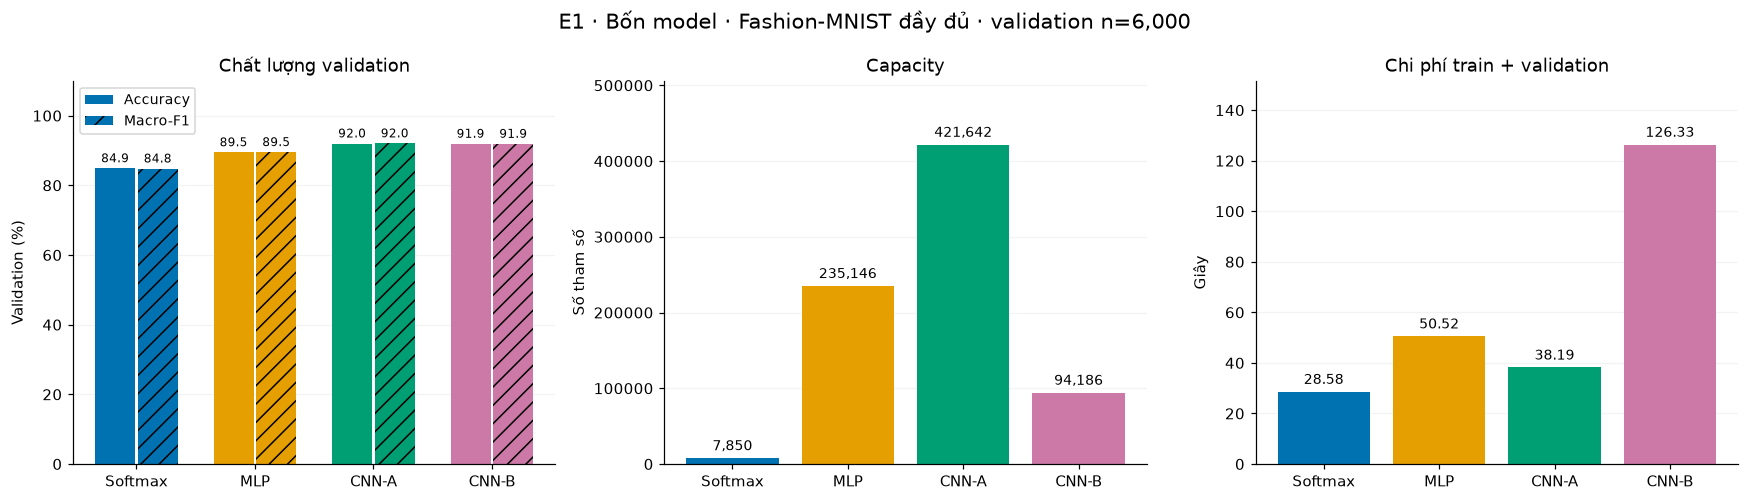

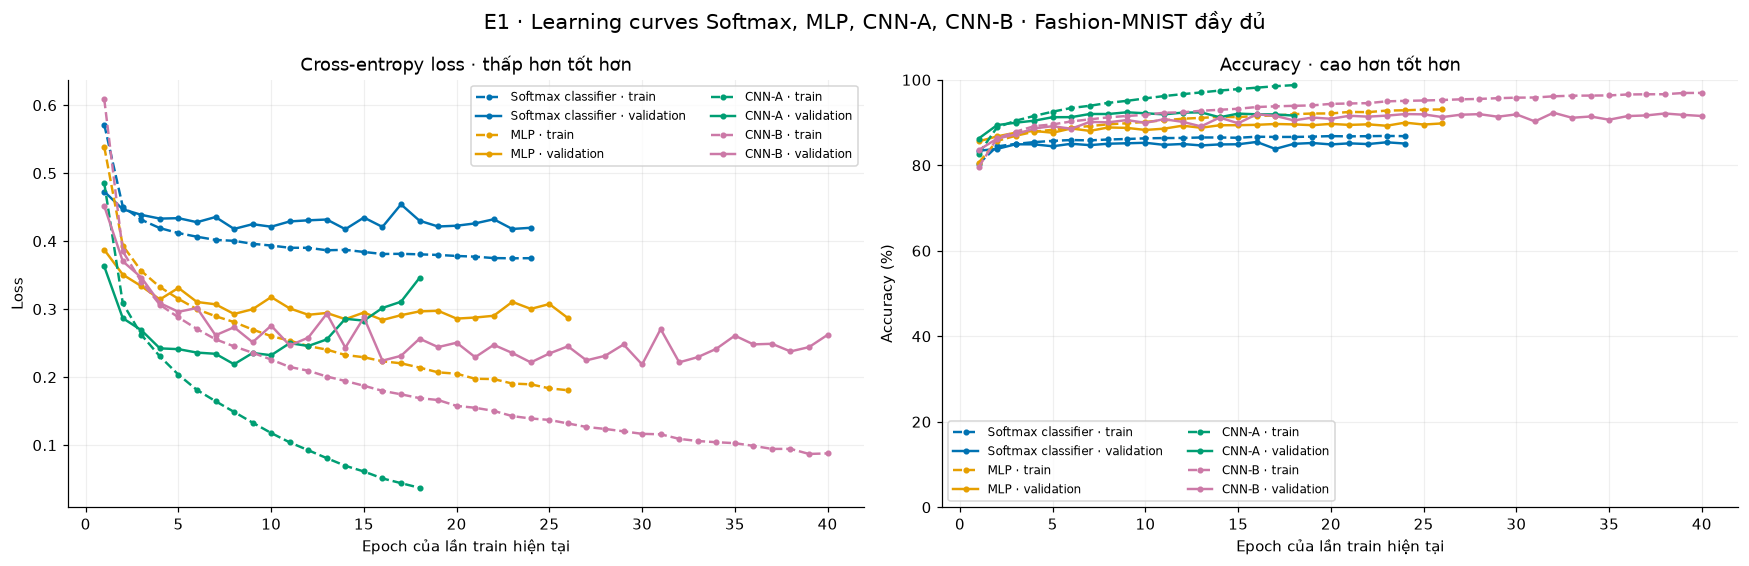

In [11]:
log(
    "BÁO CÁO KẾT QUẢ", "Hiển thị bảng metric thật, trạng thái train và hai biểu đồ gộp."
)
display_result_table(results, histories)
comparison_plot(results)
learning_curves_plot(results, histories)

## 9. Confusion matrix và ảnh lỗi trên toàn bộ test
Mỗi cặp matrix đặt ngang, tiêu đề ghi rõ Softmax classifier / MLP / CNN-A / CNN-B.
Hàng là nhãn thật, cột là dự đoán. Mỗi ô hiển thị số ảnh; ô khác 0 thêm % theo tổng hàng.
Mỗi hàng test gồm 1.000 ảnh; màu dùng cùng thang 0–100% cho cả 4 model.
Đây là **ma trận nhầm lẫn**, không phải hệ số tương quan.
Ảnh lỗi được gom thành hàng model / cột cùng lớp thật để so sánh.

[02:29:11] [BÁO CÁO LỖI] Phân tích test trên cùng tập cho bốn model.
[02:29:11] [CONFUSION MATRIX] Test: hai cặp đặt ngang; mỗi ô = số ảnh và % theo hàng.
[HÌNH] confusion_test_pair_1 · hiển thị trong output cell
[HÌNH] confusion_test_pair_2 · hiển thị trong output cell
[02:29:12] [PHÂN TÍCH LỖI] Gộp 4 lớp có recall trung bình thấp nhất; mỗi hàng một model, mỗi cột cùng lớp thật.
[HÌNH] failure_examples_test · hiển thị trong output cell


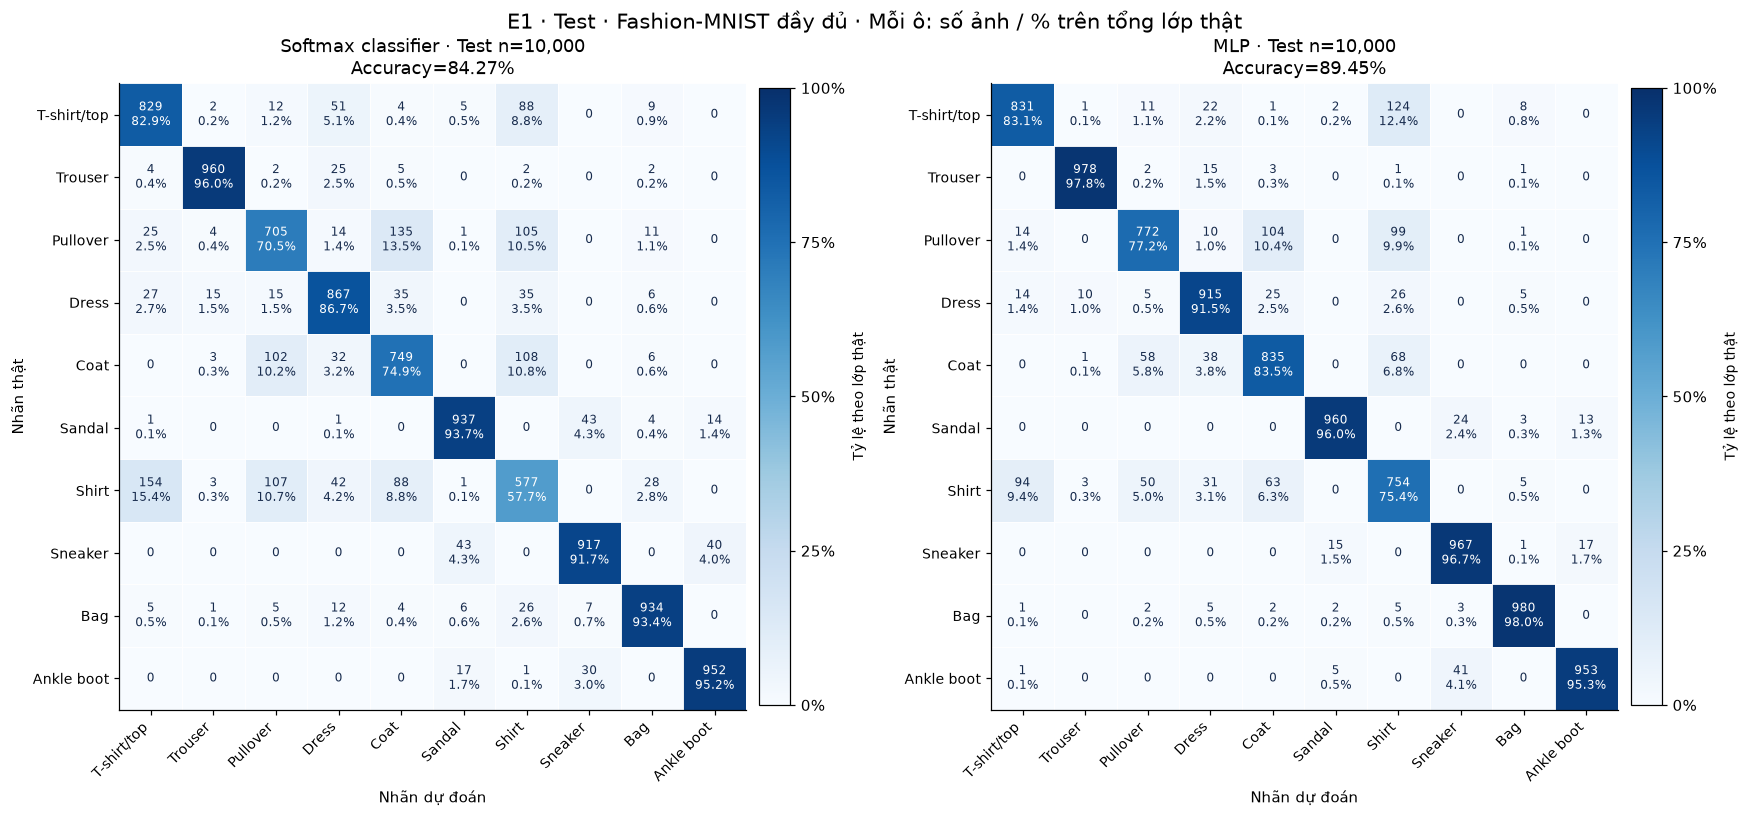

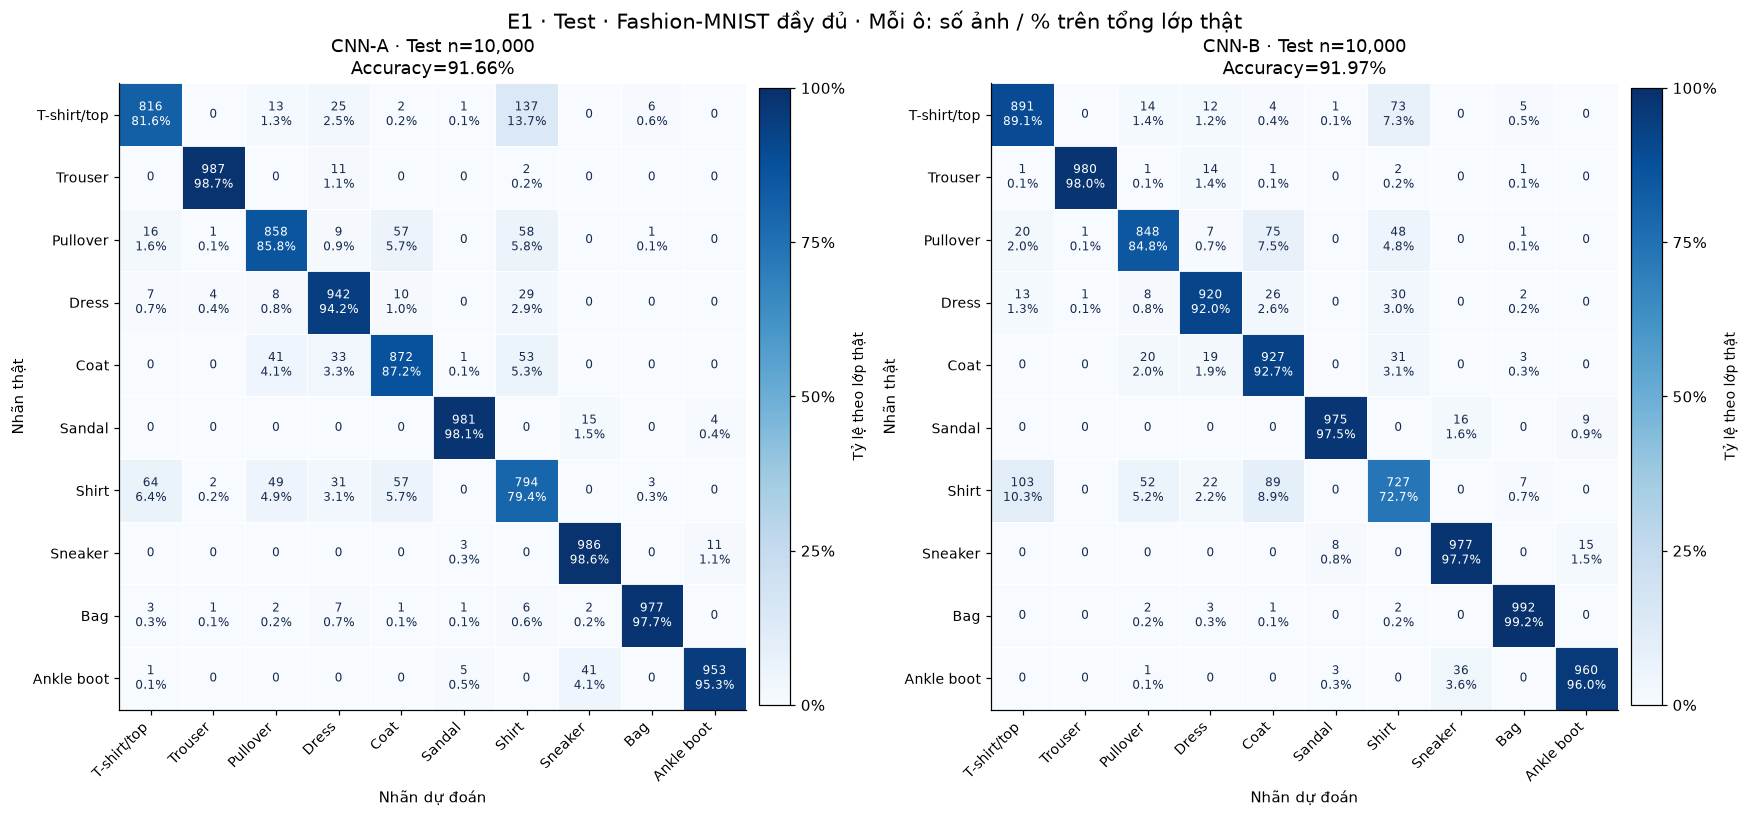

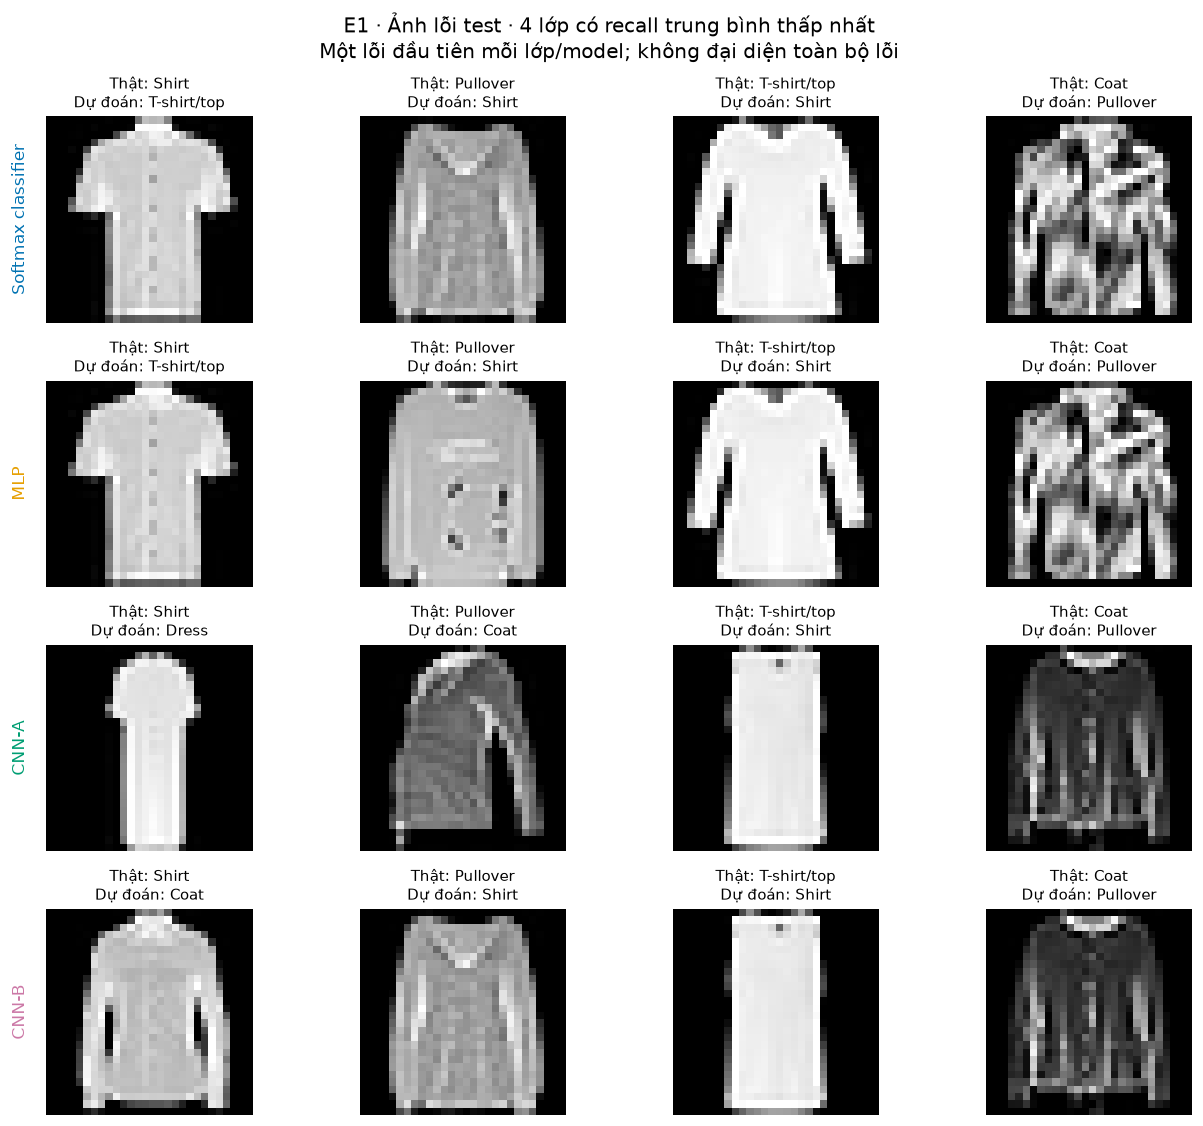

In [12]:
REPORT_SPLIT = "test"
log(
    "BÁO CÁO LỖI",
    "Phân tích test trên cùng tập cho bốn model.",
)
confusion_plots(results, evaluations, REPORT_SPLIT)
failure_examples_plot(results, evaluations, REPORT_SPLIT)

## 10. Nhận xét dựa trên số liệu thật
Tổng hợp kết quả, lớp nhầm nhiều nhất và giới hạn của thí nghiệm. Sau khi hoàn tất, lưu notebook để giữ bảng/hình và nhận xét trong output cell.

In [13]:
log("NHẬN XÉT", "Phân tích chất lượng, capacity, generalization gap và các lớp nhầm.")
by_run = {result["run"]: result for result in results}
winner = max(
    results, key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"])
)
softmax, mlp, cnn_a, cnn_b = [
    by_run[run] for run in ["linear", "mlp", "cnn_a", "cnn_b"]
]
display(
    Markdown(
        f"**Chất lượng phân loại.** {winner['model']} có validation accuracy cao nhất "
        f"({100 * winner['val_accuracy']:.2f}%). Checkpoint từng model được chọn bằng "
        f"validation loss. Trên test, MLP đạt {100 * mlp['test_accuracy']:.2f}%, tăng "
        f"{100 * (mlp['test_accuracy'] - softmax['test_accuracy']):.2f} điểm phần trăm "
        f"so với Softmax. CNN-A đạt {100 * cnn_a['test_accuracy']:.2f}% và CNN-B đạt "
        f"{100 * cnn_b['test_accuracy']:.2f}%. Kết quả phù hợp với lợi ích của phi tuyến "
        "ở MLP và đặc trưng không gian ở CNN trong thí nghiệm này.\n\n"
        f"**Capacity và chi phí.** CNN-A có {cnn_a['parameters']:,} tham số; CNN-B có "
        f"{cnn_b['parameters']:,}, tỷ lệ {cnn_a['parameters'] / cnn_b['parameters']:.2f}×. "
        f"Accuracy test của CNN-B − CNN-A là "
        f"{100 * (cnn_b['test_accuracy'] - cnn_a['test_accuracy']):+.2f} điểm phần trăm. "
        "Số tham số riêng lẻ không giải thích toàn bộ chất lượng hoặc tốc độ: hai CNN "
        "còn khác pooling/head/batch normalization, và thời gian tổng phụ thuộc early stopping."
    )
)
gap_lines = [
    "| Model | Train acc tại best (%) | Val acc (%) | Train − val (điểm %) |",
    "|---|---:|---:|---:|",
]
for result in results:
    best = next(
        row for row in histories[result["run"]] if row["epoch"] == result["best_epoch"]
    )
    gap_lines.append(
        f"| {result['model']} | {100 * best['train_accuracy']:.2f} | "
        f"{100 * result['val_accuracy']:.2f} | "
        f"{100 * (best['train_accuracy'] - result['val_accuracy']):+.2f} |"
    )
display(
    Markdown("**Train/validation gap tại checkpoint chọn**\n\n" + "\n".join(gap_lines))
)
display(
    Markdown(
        "Train accuracy ở đây là số đo trong train mode khi cập nhật weights; "
        "validation dùng eval mode. Đọc gap cùng learning curves: training loss tiếp tục "
        "giảm trong khi validation loss dao động là dấu hiệu cần dừng và chọn checkpoint. "
        "Early stopping giữ weights có validation loss thấp nhất."
    )
)
lines = [
    "| Model | Nhầm nhiều nhất (thật → dự đoán) | Số ảnh | % lớp thật |",
    "|---|---|---:|---:|",
]
for result in results:
    cm = evaluations[result["run"]]["test"]["cm"]
    off_diagonal = cm.copy()
    np.fill_diagonal(off_diagonal, 0)
    truth, prediction = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
    count = int(off_diagonal[truth, prediction])
    percentage = 100 * count / max(1, int(cm[truth].sum()))
    pair = (
        f"{CLASS_NAMES[truth]} → {CLASS_NAMES[prediction]}"
        if count
        else "Không có dự đoán sai"
    )
    lines.append(f"| {result['model']} | {pair} | {count} | {percentage:.1f}% |")
display(Markdown("**Các cặp lớp nhầm nhiều nhất trên test**\n\n" + "\n".join(lines)))
display(
    Markdown(
        "Confusion matrix và ảnh lỗi cho thấy các nhầm lẫn giữa nhóm áo có hình dáng "
        "gần nhau cần được phân tích riêng với lớp giày hoặc túi. Gallery lấy lỗi đầu "
        "tiên theo lớp/model; tần suất lỗi được đánh giá bằng toàn bộ confusion matrix. "
        "Thí nghiệm dùng một seed, vì vậy chênh lệch nhỏ giữa hai model cần được đọc "
        "cùng giới hạn biến thiên giữa các lần huấn luyện."
    )
)
finish_notebook()
log(
    "HOÀN TẤT E1",
    f"Tổng thời gian train + validation: {sum(r['seconds'] for r in results):.2f}s.",
)

[03:09:18] [NHẬN XÉT] Phân tích chất lượng, capacity, generalization gap và các lớp nhầm.


**Chất lượng phân loại.** CNN-A có validation accuracy cao nhất (92.00%). Checkpoint từng model được chọn bằng validation loss. Trên test, MLP đạt 89.45%, tăng 5.18 điểm phần trăm so với Softmax. CNN-A đạt 91.66% và CNN-B đạt 91.97%. Kết quả phù hợp với lợi ích của phi tuyến ở MLP và đặc trưng không gian ở CNN trong thí nghiệm này.

**Capacity và chi phí.** CNN-A có 421,642 tham số; CNN-B có 94,186, tỷ lệ 4.48×. Accuracy test của CNN-B − CNN-A là +0.31 điểm phần trăm. Số tham số riêng lẻ không giải thích toàn bộ chất lượng hoặc tốc độ: hai CNN còn khác pooling/head/batch normalization, và thời gian tổng phụ thuộc early stopping.

**Train/validation gap tại checkpoint chọn**

| Model | Train acc tại best (%) | Val acc (%) | Train − val (điểm %) |
|---|---:|---:|---:|
| Softmax classifier | 86.51 | 84.88 | +1.62 |
| MLP | 91.58 | 89.47 | +2.11 |
| CNN-A | 94.61 | 92.00 | +2.61 |
| CNN-B | 95.82 | 91.92 | +3.91 |

Train accuracy ở đây là số đo trong train mode khi cập nhật weights; validation dùng eval mode. Đọc gap cùng learning curves: training loss tiếp tục giảm trong khi validation loss dao động là dấu hiệu cần dừng và chọn checkpoint. Early stopping giữ weights có validation loss thấp nhất.

**Các cặp lớp nhầm nhiều nhất trên test**

| Model | Nhầm nhiều nhất (thật → dự đoán) | Số ảnh | % lớp thật |
|---|---|---:|---:|
| Softmax classifier | Shirt → T-shirt/top | 154 | 15.4% |
| MLP | T-shirt/top → Shirt | 124 | 12.4% |
| CNN-A | T-shirt/top → Shirt | 137 | 13.7% |
| CNN-B | Shirt → T-shirt/top | 103 | 10.3% |

Confusion matrix và ảnh lỗi cho thấy các nhầm lẫn giữa nhóm áo có hình dáng gần nhau cần được phân tích riêng với lớp giày hoặc túi. Gallery lấy lỗi đầu tiên theo lớp/model; tần suất lỗi được đánh giá bằng toàn bộ confusion matrix. Thí nghiệm dùng một seed, vì vậy chênh lệch nhỏ giữa hai model cần được đọc cùng giới hạn biến thiên giữa các lần huấn luyện.

[03:09:18] [THÍ NGHIỆM] Hoàn tất đánh giá 4 model trên toàn bộ test.


[03:09:18] [HOÀN TẤT E1] Tổng thời gian train + validation: 243.61s.



## 11. Tái lập thí nghiệm

Chọn kernel **Python 3.14 có PyTorch CUDA**, mở notebook trong `source_code`,
rồi **Restart Kernel → Run All**. Dữ liệu: toàn bộ Fashion-MNIST đã chia thành
54.000 train / 6.000 validation / 10.000 test. Seed42, AdamW, batch128;
giới hạn100 epoch, patience4, min_delta0,0001.

Code, training loop, kiểm chứng và trình bày kết quả nằm trong notebook này.
`RUN_CONFIGS` giữ cấu hình mỗi model; `histories` giữ metric từng epoch;
`evaluations` giữ ma trận và ví dụ lỗi; `EXECUTION_LOG` giữ log chi tiết trong RAM.
Checkpoint tốt nhất giữ trong CPU RAM cho đến khi hoàn tất đánh giá.

Bảng, hình, tiến trình và nhận xét hiển thị trong output cell.
**Save notebook** để lưu toàn bộ kết quả vào file `.ipynb`.
Nguồn dữ liệu và định dạng: [datasets/README](../datasets/README.md).
Đề bài: [exercise-vne.pdf](../assignment/exercise-vne.pdf).

Người thực hiện cần kiểm chứng, giải thích code/số liệu và khai báo phần AI hỗ trợ
theo mục1.6 của đề trước khi nộp.
